# Lecture 10: Potential Outcomes & The Causal Inference Problem
**BANA 4373 / ECON 4370 — Applied Data Tools for Economics & Business**  
**Dr. Fidel González — Spring 2026**

This notebook is designed to run *seamlessly in class* **without any external downloads**.  
We use Cunningham's (2021) surgery vs. chemo example from *Causal Inference: The Mixtape*, Ch. 4, to:

- Define potential outcomes, the switching equation, and the fundamental problem of causal inference
- Compute **ATE**, **ATT**, and **ATU** from a complete potential-outcomes table
- Decompose the **Simple Difference in Outcomes (SDO)** into ATE + Selection Bias + HTE Bias
- Simulate **randomization** and show that both biases vanish

> **Reference:** Cunningham, Scott (2021). *Causal Inference: The Mixtape.* Yale University Press.  
> Free online: [https://mixtape.scunning.com/04-potential_outcomes](https://mixtape.scunning.com/04-potential_outcomes)

---
## 0) Learning Objectives
By the end of this notebook, you can:

1. Explain why a causal effect requires **two** potential outcomes but we only observe **one**.
2. Calculate ATE, ATT, and ATU from a potential-outcomes table.
3. Decompose the SDO and identify **selection bias** and **heterogeneous treatment effect bias**.
4. Show via simulation that **randomization** eliminates both biases.

> **Correlation is not causation — this notebook shows you *exactly* why, and what to do about it.**

In [6]:
# 1) Setup
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
np.random.seed(42)

print("Setup complete.")

Setup complete.


---
## 2) The Potential Outcomes Framework

### The Setup
There are 10 cancer patients. Two treatments exist:
- **Surgery** (D = 1)
- **Chemotherapy** (D = 0)

Each patient has **two potential outcomes** — the number of additional years they would live under each treatment.  
This is the God's-eye view that we **never** have in practice.

### The Switching Equation

$$Y_i = D_i \cdot Y_i^1 + (1 - D_i) \cdot Y_i^0$$

When $D_i = 1$, we observe $Y_i^1$ and $Y_i^0$ is **missing**.  
When $D_i = 0$, we observe $Y_i^0$ and $Y_i^1$ is **missing**.  

This is the **fundamental problem of causal inference**: we can never observe both potential outcomes for the same person at the same time.

In [8]:
# ──────────────────────────────────────────────
# Table 4.2 from Cunningham (2021): Full Potential Outcomes
# ──────────────────────────────────────────────

df = pd.DataFrame({
    "patient":  list(range(1, 11)),
    "y1":       [7, 5, 5, 7, 4, 10, 1, 5, 3, 9],   # Y^1: outcome under surgery
    "y0":       [1, 6, 1, 8, 2,  1, 10, 6, 7, 8],   # Y^0: outcome under chemo
})

# Individual treatment effect
df["delta"] = df["y1"] - df["y0"]

print("Table 4.2: Complete potential outcomes (the 'God view')")
print("=" * 55)
df

Table 4.2: Complete potential outcomes (the 'God view')


,patient,y1,y0,delta
0,1,7,1,6
1,2,5,6,-1
2,3,5,1,4
3,4,7,8,-1
4,5,4,2,2
5,6,10,1,9
6,7,1,10,-9
7,8,5,6,-1
8,9,3,7,-4
9,10,9,8,1


### ✍️ Your Turn: Before running the next cell

Look at the `delta` column above.

1. Which patient benefits **most** from surgery?  
2. Which patient is **harmed most** by surgery?  
3. Does surgery help *everyone*? What does this tell you about treatment effect **heterogeneity**?

**Your answers:**

1. Patient who benefits most: ___
2. Patient harmed most: ___
3. Does surgery help everyone? ___

---
## 3) Computing ATE, ATT, and ATU

Three causal parameters of interest:

| Parameter | Formula | Meaning |
|-----------|---------|--------|
| **ATE**   | $E[Y^1] - E[Y^0]$ | Average effect across *everyone* |
| **ATT**   | $E[Y^1 \mid D=1] - E[Y^0 \mid D=1]$ | Average effect for the *treated group* |
| **ATU**   | $E[Y^1 \mid D=0] - E[Y^0 \mid D=0]$ | Average effect for the *untreated group* |

Key relationship: **ATE = π · ATT + (1−π) · ATU**, where π is the share treated.

In [12]:
# ──────────────────────────────────────────────
# Step 1: Compute the ATE (uses the FULL table — the God view)
# ──────────────────────────────────────────────

ATE = df["y1"].mean() - df["y0"].mean()

print(f"E[Y¹] = {df['y1'].mean():.1f}")
print(f"E[Y⁰] = {df['y0'].mean():.1f}")
print(f"ATE   = {ATE:.1f}")
print()
print("Interpretation: On average, surgery adds 0.6 years of life.")
print("But NOT everyone benefits — treatment effects are heterogeneous.")

E[Y¹] = 5.6
E[Y⁰] = 5.0
ATE   = 0.6

Interpretation: On average, surgery adds 0.6 years of life.
But NOT everyone benefits — treatment effects are heterogeneous.


---
## 4) The "Perfect Doctor" — Endogenous Treatment Assignment

Now suppose a doctor who *knows* each patient's potential outcomes assigns each to whichever treatment maximizes their lifespan.

- If $Y^1_i > Y^0_i$ → patient gets **surgery** (D = 1)
- If $Y^1_i < Y^0_i$ → patient gets **chemo** (D = 0)

This is *optimal* for the patient, but it means treatment depends on potential outcomes — **independence is violated**.

In [14]:
# ──────────────────────────────────────────────
# The "perfect doctor" assigns treatment
# ──────────────────────────────────────────────

df["D"] = (df["y1"] > df["y0"]).astype(int)

# The switching equation: observed outcome
df["Y_obs"] = df["D"] * df["y1"] + (1 - df["D"]) * df["y0"]

print("Table 4.3: Observed outcomes after the 'perfect doctor' assigns treatment")
print("=" * 65)
df[["patient", "Y_obs", "D"]].rename(
    columns={"Y_obs": "Y (observed)", "D": "D (1=surgery, 0=chemo)"}
)

Table 4.3: Observed outcomes after the 'perfect doctor' assigns treatment


,patient,Y (observed),"D (1=surgery, 0=chemo)"
0,1,7,1
1,2,6,0
2,3,5,1
3,4,8,0
4,5,4,1
5,6,10,1
6,7,10,0
7,8,6,0
8,9,7,0
9,10,9,1


In [15]:
# ──────────────────────────────────────────────
# Step 2: Compute ATT and ATU
# (We can do this because we still have the full table)
# ──────────────────────────────────────────────

treated   = df[df["D"] == 1]
untreated = df[df["D"] == 0]

ATT = treated["delta"].mean()
ATU = untreated["delta"].mean()
pi  = len(treated) / len(df)

print(f"ATT = E[δ | D=1] = {ATT:.1f}")
print(f"ATU = E[δ | D=0] = {ATU:.1f}")
print(f"π   = share treated = {pi:.1f}")
print()
print(f"Verify: ATE = π·ATT + (1-π)·ATU = {pi}×{ATT} + {1-pi}×{ATU} = {pi*ATT + (1-pi)*ATU:.1f}")
print()
print("Notice: ATT = 4.4 (surgery HELPS the surgery group)")
print("        ATU = -3.2 (surgery would HURT the chemo group)")
print("        The doctor did a good job — but this creates selection bias!")

ATT = E[δ | D=1] = 4.4
ATU = E[δ | D=0] = -3.2
π   = share treated = 0.5

Verify: ATE = π·ATT + (1-π)·ATU = 0.5×4.4 + 0.5×-3.2 = 0.6

Notice: ATT = 4.4 (surgery HELPS the surgery group)
        ATU = -3.2 (surgery would HURT the chemo group)
        The doctor did a good job — but this creates selection bias!


---
## 5) The Simple Difference in Outcomes (SDO)

A naïve researcher who only sees the observed data (Table 4.3) computes:

$$\text{SDO} = E[Y^1 \mid D=1] - E[Y^0 \mid D=0]$$

This is just the difference in average outcomes between the surgery and chemo groups.

In [17]:
# ──────────────────────────────────────────────
# Step 3: Compute the SDO — what a naïve researcher would calculate
# ──────────────────────────────────────────────

mean_treated   = treated["Y_obs"].mean()
mean_untreated = untreated["Y_obs"].mean()
SDO = mean_treated - mean_untreated

print(f"Mean outcome, surgery group: {mean_treated:.1f}")
print(f"Mean outcome, chemo group:   {mean_untreated:.1f}")
print(f"SDO = {mean_treated:.1f} - {mean_untreated:.1f} = {SDO:.1f}")
print()
print("⚠️  The SDO is NEGATIVE (-0.4), suggesting surgery is harmful!")
print("    But we KNOW the true ATE is +0.6. What went wrong?")

Mean outcome, surgery group: 7.0
Mean outcome, chemo group:   7.4
SDO = 7.0 - 7.4 = -0.4

⚠️  The SDO is NEGATIVE (-0.4), suggesting surgery is harmful!
    But we KNOW the true ATE is +0.6. What went wrong?


---
## 6) The SDO Decomposition — Where the Bias Comes From

We can decompose the SDO into three parts:

$$\underbrace{E[Y^1|D=1] - E[Y^0|D=0]}_{\text{SDO (what we compute)}} = \underbrace{E[Y^1] - E[Y^0]}_{\text{ATE (what we want)}} + \underbrace{E[Y^0|D=1] - E[Y^0|D=0]}_{\text{Selection Bias}} + \underbrace{(1-\pi)(ATT - ATU)}_{\text{HTE Bias}}$$

Let's compute each piece.

In [19]:
# ──────────────────────────────────────────────
# Step 4: Decompose the SDO
# ──────────────────────────────────────────────

# --- Selection Bias ---
# E[Y⁰ | D=1]: what would the surgery group's outcome be under chemo?
E_y0_treated   = treated["y0"].mean()
# E[Y⁰ | D=0]: the chemo group's actual outcome under chemo
E_y0_untreated = untreated["y0"].mean()

selection_bias = E_y0_treated - E_y0_untreated

# --- Heterogeneous Treatment Effect Bias ---
hte_bias = (1 - pi) * (ATT - ATU)

print("╔══════════════════════════════════════════════════════════════╗")
print("║             SDO DECOMPOSITION (Step by Step)               ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  ATE             = E[Y¹] - E[Y⁰]           =  {ATE:+.1f}       ║")
print(f"║  Selection Bias  = E[Y⁰|D=1] - E[Y⁰|D=0]  =  {selection_bias:+.1f}       ║")
print(f"║    where E[Y⁰|D=1] = {E_y0_treated:.1f}, E[Y⁰|D=0] = {E_y0_untreated:.1f}              ║")
print(f"║  HTE Bias        = (1-π)(ATT - ATU)         =  {hte_bias:+.1f}       ║")
print(f"║    where (1-{pi})({ATT} - ({ATU})) = {hte_bias:.1f}              ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  SDO = ATE + Sel.Bias + HTE Bias                          ║")
print(f"║  {SDO:.1f} = {ATE:.1f} + ({selection_bias:.1f}) + {hte_bias:.1f}                       ║")
print(f"║  {SDO:.1f} = {ATE + selection_bias + hte_bias:.1f}   ✓                                  ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║             SDO DECOMPOSITION (Step by Step)               ║
╠══════════════════════════════════════════════════════════════╣
║  ATE             = E[Y¹] - E[Y⁰]           =  +0.6       ║
║  Selection Bias  = E[Y⁰|D=1] - E[Y⁰|D=0]  =  -4.8       ║
║    where E[Y⁰|D=1] = 2.6, E[Y⁰|D=0] = 7.4              ║
║  HTE Bias        = (1-π)(ATT - ATU)         =  +3.8       ║
║    where (1-0.5)(4.4 - (-3.2)) = 3.8              ║
╠══════════════════════════════════════════════════════════════╣
║  SDO = ATE + Sel.Bias + HTE Bias                          ║
║  -0.4 = 0.6 + (-4.8) + 3.8                       ║
║  -0.4 = -0.4   ✓                                  ║
╚══════════════════════════════════════════════════════════════╝


### Interpreting Each Piece

**Selection Bias = −4.8**  
The surgery group has a much worse baseline prognosis than the chemo group (under chemo, they'd only live 2.6 years vs. 7.4 years). Why? Because the "perfect doctor" sent the sickest patients — those who would do poorly on chemo — to surgery. The groups are fundamentally different *at baseline*.

**HTE Bias = +3.8**  
The treatment effect differs across the two groups: ATT = 4.4 (surgery helps a lot) vs. ATU = −3.2 (surgery would hurt). Because people sorted into treatment based on their expected gains, the SDO confounds the true average effect with this differential gain.

**The Bottom Line:**  
The SDO of −0.4 "contains" the ATE of 0.6, but it's hidden under two layers of bias. In practice, we cannot calculate these biases because they depend on **unobservable counterfactual outcomes**.

### ✍️ Your Turn: Think before you code

Suppose someone shows you data from a job-training program and says:

> *"Workers who did the training earn \$5,000 more per year than those who didn't. So the program works!"*

Using the framework we just built, write 2–3 sentences explaining:
1. Why this SDO might **not** equal the causal effect (ATE).
2. In which **direction** would you expect the selection bias to go?


**Your answer:**

*Write here...*

---
## 7) Randomization: The Solution

The **independence assumption** states:

$$(Y^1, Y^0) \perp D$$

Treatment was assigned for reasons having **nothing to do** with potential outcomes. When this holds:

- **Selection Bias = 0** because $E[Y^0 | D=1] = E[Y^0 | D=0]$
- **HTE Bias = 0** because $ATT = ATU$ (groups are exchangeable)
- Therefore: **SDO = ATE** 🎉

**How do we guarantee independence?** Flip a coin. Use a random number generator. Physical randomization ensures that no human judgment or self-selection contaminates the assignment.

Let's simulate this.

In [24]:
# ──────────────────────────────────────────────
# Step 5: Simulate random assignment (Monte Carlo)
# 
# Same 10 patients, same potential outcomes.
# But now we assign treatment RANDOMLY.
# We repeat 10,000 times and check: does SDO → ATE?
# ──────────────────────────────────────────────

y1 = np.array([7, 5, 5, 7, 4, 10, 1, 5, 3, 9])
y0 = np.array([1, 6, 1, 8, 2,  1, 10, 6, 7, 8])

n_sims = 10_000
sdo_list = []

for _ in range(n_sims):
    # Random assignment: shuffle and pick first 5 as treated
    order = np.random.permutation(10)
    d = np.zeros(10, dtype=int)
    d[order[:5]] = 1
    
    # Observed outcomes via switching equation
    y_obs = d * y1 + (1 - d) * y0
    
    # SDO for this random assignment
    sdo = y_obs[d == 1].mean() - y_obs[d == 0].mean()
    sdo_list.append(sdo)

sdo_array = np.array(sdo_list)

print(f"True ATE:                       {ATE:.2f}")
print(f"Average SDO across {n_sims:,} random assignments: {sdo_array.mean():.4f}")
print(f"Std. dev. of SDO:               {sdo_array.std():.4f}")
print()
print("✅ Under random assignment, the SDO converges to the ATE!")
print("   Both biases have been eliminated — on average, the groups are identical.")

True ATE:                       0.60
Average SDO across 10,000 random assignments: 0.5964
Std. dev. of SDO:               1.1108

✅ Under random assignment, the SDO converges to the ATE!
   Both biases have been eliminated — on average, the groups are identical.


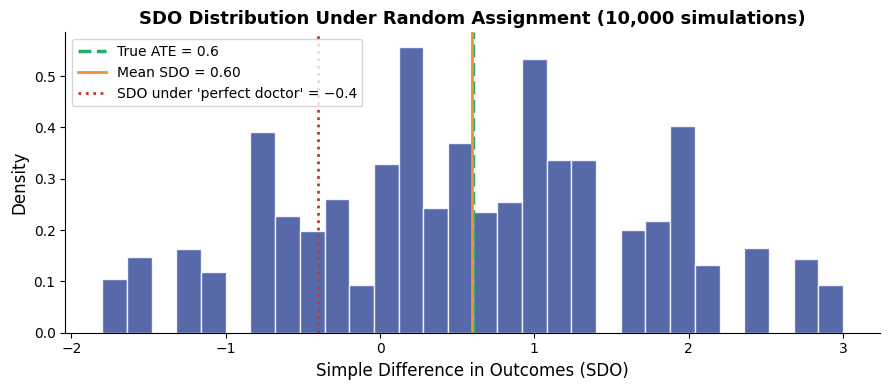

In [25]:
# ──────────────────────────────────────────────
# Visualize: Distribution of SDO under random assignment
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sdo_array, bins=30, color="#3A4F9A", edgecolor="white", alpha=0.85, density=True)
ax.axvline(ATE, color="#27AE60", linewidth=2.5, linestyle="--", label=f"True ATE = {ATE:.1f}")
ax.axvline(sdo_array.mean(), color="#E8943A", linewidth=2, linestyle="-", label=f"Mean SDO = {sdo_array.mean():.2f}")
ax.axvline(-0.4, color="#C0392B", linewidth=2, linestyle=":", label="SDO under 'perfect doctor' = −0.4")

ax.set_xlabel("Simple Difference in Outcomes (SDO)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("SDO Distribution Under Random Assignment (10,000 simulations)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### What the histogram shows

- The **green dashed line** is the true ATE (0.6).
- The **orange line** is the mean SDO across all random assignments — it sits right on top of the ATE.
- The **red dotted line** is the biased SDO (−0.4) from the "perfect doctor" scenario. Notice how far it is from the truth!
- Any single random assignment gives a noisy estimate, but **on average** we recover the correct causal effect.

---
## 8) Verifying: Both Biases Vanish Under Randomization

Let's go one step further. For each random assignment, we'll compute:
- Selection Bias
- HTE Bias

and confirm they average to zero.

In [28]:
# ──────────────────────────────────────────────
# Step 6: Track both biases under random assignment
# ──────────────────────────────────────────────

sel_bias_list = []
hte_bias_list = []

for _ in range(n_sims):
    order = np.random.permutation(10)
    d = np.zeros(10, dtype=int)
    d[order[:5]] = 1
    
    # Selection bias: E[Y⁰|D=1] - E[Y⁰|D=0]
    sb = y0[d == 1].mean() - y0[d == 0].mean()
    sel_bias_list.append(sb)
    
    # HTE bias: (1-π)(ATT_sim - ATU_sim)
    delta = y1 - y0
    att_sim = delta[d == 1].mean()
    atu_sim = delta[d == 0].mean()
    pi_sim  = d.mean()
    hb = (1 - pi_sim) * (att_sim - atu_sim)
    hte_bias_list.append(hb)

print("Average biases across 10,000 random assignments:")
print(f"  Selection Bias:  {np.mean(sel_bias_list):+.4f}  (should be ≈ 0)")
print(f"  HTE Bias:        {np.mean(hte_bias_list):+.4f}  (should be ≈ 0)")
print()
print("Compare to the 'perfect doctor' scenario:")
print(f"  Selection Bias:  {selection_bias:+.1f}")
print(f"  HTE Bias:        {hte_bias:+.1f}")
print()
print("✅ Randomization drives both biases to zero!")

Average biases across 10,000 random assignments:
  Selection Bias:  +0.0176  (should be ≈ 0)
  HTE Bias:        -0.0140  (should be ≈ 0)

Compare to the 'perfect doctor' scenario:
  Selection Bias:  -4.8
  HTE Bias:        +3.8

✅ Randomization drives both biases to zero!


---
## 9) Summary Table: Perfect Doctor vs. Randomization

Let's put it all together in one comparison.

In [30]:
# ──────────────────────────────────────────────
# Summary comparison
# ──────────────────────────────────────────────

summary = pd.DataFrame({
    "Component": ["ATE (truth)", "Selection Bias", "HTE Bias", "SDO (estimated)"],
    "Perfect Doctor": [0.6, -4.8, 3.8, -0.4],
    "Random Assignment (avg)": [0.6, round(np.mean(sel_bias_list), 2), 
                                round(np.mean(hte_bias_list), 2),
                                round(np.mean(sdo_list), 2)]
}).set_index("Component")

print("SDO Decomposition: Endogenous vs. Random Assignment")
print("=" * 60)
summary

SDO Decomposition: Endogenous vs. Random Assignment


,Perfect Doctor,Random Assignment (avg)
Component,,
ATE (truth),0.6,0.60
Selection Bias,-4.8,0.02
HTE Bias,3.8,-0.01
SDO (estimated),-0.4,0.60


---
## 10) SUTVA: The Fine Print

The potential outcomes framework relies on the **Stable Unit Treatment Value Assumption (SUTVA)**:

1. **No variation in treatment doses** — every treated unit gets the same treatment.
2. **No spillovers** — treating unit *i* doesn't affect unit *j*'s outcome.
3. **No general equilibrium effects** — scaling up the treatment doesn't change the environment.

**Think about violations:**
- Vaccinating one person protects others (spillover → violates SUTVA).
- Sending everyone to college would change the wage premium (general equilibrium).
- Some surgeons are better than others (dose variation).

### ✍️ Your Turn: SUTVA Violations

For each scenario below, identify which SUTVA assumption is most likely violated and explain why in one sentence:

1. A study measures the effect of a new teaching method on test scores. Students in the treatment group share study tips with control-group friends.
2. A state evaluates the impact of a job-training program using 50 participants. The state then considers rolling it out to 500,000 workers.
3. An experiment tests a drug at a single hospital, but some doctors administer it more carefully than others.


**Your answers:**

1. *Write here...*
2. *Write here...*
3. *Write here...*

---
## 11) Key Takeaways

1. **The fundamental problem of causal inference**: we only observe *one* potential outcome per unit. The counterfactual is always missing.

2. **Three parameters**: ATE (everyone), ATT (treated), ATU (untreated). The ATE is a weighted average of ATT and ATU.

3. **The SDO decomposition**: SDO = ATE + Selection Bias + HTE Bias. Naïve comparisons almost never equal causal effects.

4. **Selection bias** = groups differ at baseline. **HTE bias** = groups have different treatment effects and we're targeting the ATE.

5. **Randomization** eliminates both biases by making treatment assignment independent of potential outcomes.

6. **SUTVA** must hold: no dose variation, no spillovers, no general equilibrium effects.

> **Next up**: Difference-in-Differences — what do we do when randomization isn't possible?

---
## 📚 Further Reading

- **Cunningham (2021)**, *Causal Inference: The Mixtape*, Ch. 4 — free at [mixtape.scunning.com](https://mixtape.scunning.com/04-potential_outcomes)  
- **Angrist & Pischke (2009)**, *Mostly Harmless Econometrics*, Ch. 2  
- **Huntington-Klein (2021)**, *The Effect*, Chs. 8–10 — free at [theeffectbook.net](https://theeffectbook.net)